# Domácí úkol

## Instrukce k odevzdávání
- Odevzdává se vyplněný notebook `DU3.ipynb` v repozitáři na GitHubu.
- Repozitář pro odevzdávání je `vvp-DU` a musí být veřejný na GitHubu.
- Základní část úkolu je hodnocena za 10 bodů.
- Část „Bonusové úkoly“ není součástí základního hodnocení (10 b) a je hodnocena za +2 body navíc (do maxima 50 b za domácí úkoly celkem).
- Vypracovaný úkol je potřeba pushnout do GitHubu; doporučuje se ověřit, že je pushnutý aktuální stav.
- Kontrola probíhá vždy den (nejpozději v 6:00 tam úkol musí být) před následujícím cvičením/tutoriálem; hodnotí se aktuální stav repozitáře.
- Nemažte ze souboru části se zadáním.
- Před termínem odevzdání restartujte kernel a ověřte, že je notebook plně spustitelný.
- Odevzdaný notebook nechte včetně výstupů.
- Nekopírujte řešení od kolegů; při nejasnostech se ptejte na princip, ne na hotové řešení.
- AI nástroje (Copilot, ChatGPT, Bard apod.) můžete používat, ale musíte rozumět odevzdanému řešení; slepý copy-paste bez porozumění (tedy neschopnosti odpovědět na dotaz k vašemu odevzdanému řešení) může vést k hodnocení 0 b.

## Část 1: Číselná spirála

Vytvořte čtvercovou matici o lichém počtu řádků a sloupců, která bude obsahovat čísla od 1 do $n^2$ tak, aby číslo 1 bylo uprostřed matice a číselná řada postupně narůstala po spirále proti směru hodinových ručiček.
- udělejte to pomocí NumPy přiřazování sliců do pole,
- výstup musí být stejný jako u primitivní funkce `integer_spiral` níže,
- vyplňujte matici po „kruzích“ okolo středu,
    - každý kruh je tvořen 4 částmi (hrana bez jednoho rohu),
    - využijte možnosti přiřazování sliců do pole a indexace s krokem `-1`,
    - použijte `np.arange` pro vytvoření řady čísel, kterou budete ukládat do hrany,
- pomozte si také okrajem z nul, který nakonec oříznete.

**Výsledná funkce bude mít tedy pouze jednu smyčku, ve které do pole vstoupíte pouze 4x (jednou za každou hranu).**

**Na závěr porovnejte rychlost vaší funkce s `integer_spiral` níže pomocí `%timeit` a různých velikostí výsledných matic (např. 101, 1001, 10001).**


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# naplnění matice spirálou čísel
def integer_spiral(n):
    # abychom nemuseli řešit okraj = kontrolovat jestli jsme mimo matici
    # vytvoříme matici o velikosti n+2 x n+2
    # a vyplníme pouze středovou část
    A = np.zeros((n + 2, n + 2))

    pos_row = n//2 + 1  # počáteční pozice: střed matice
    pos_col = n//2 + 1

    i = 1  # číslo, které se bude vkládat do matice

    A[pos_row, pos_col] = i  # vložíme číslo do středu matice
    i += 1
    pos_col += 1  # posuneme se na první volné místo

    while i <= n**2:  # dokud nejsme na konci matice
        A[pos_row, pos_col] = i  # vložíme číslo na aktuální pozici
        i += 1  # zvýšíme číslo, které se má vložit
        if A[pos_row - 1, pos_col] != 0 and A[pos_row, pos_col + 1] == 0:
            pos_col += 1  # posuneme se doprava
        elif A[pos_row, pos_col - 1] != 0:
            pos_row -= 1  # posuneme se nahoru
        elif A[pos_row + 1, pos_col] != 0:
            pos_col -= 1  # posuneme se doleva
        else:
            pos_row += 1  # posuneme se dolů

    return A[1:-1, 1:-1]  # ořízneme nulový okraj


In [3]:
A = integer_spiral(7)
print(A)

[[37. 36. 35. 34. 33. 32. 31.]
 [38. 17. 16. 15. 14. 13. 30.]
 [39. 18.  5.  4.  3. 12. 29.]
 [40. 19.  6.  1.  2. 11. 28.]
 [41. 20.  7.  8.  9. 10. 27.]
 [42. 21. 22. 23. 24. 25. 26.]
 [43. 44. 45. 46. 47. 48. 49.]]


In [4]:
def integer_spiral_numpy(n):
    A = np.zeros((n + 2, n + 2), dtype=int)
    c = n // 2 + 1
    A[c, c] = 1
    val = 2

    for k in range(1, n // 2 + 1):
        s = 2 * k
        top = c - k
        bottom = c + k
        left = c - k
        right = c + k

        A[bottom:top:-1, left] = np.arange(val, val + s)
        val += s

        A[top, left:right] = np.arange(val, val + s)
        val += s

        A[top:bottom, right] = np.arange(val, val + s)
        val += s

        A[bottom, right:left:-1] = np.arange(val, val + s)
        val += s

    return A[1:-1, 1:-1]

In [6]:
%timeit integer_spiral_numpy(101)
%timeit integer_spiral(101)

%timeit integer_spiral_numpy(1001)
%timeit integer_spiral(1001)

253 μs ± 10.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
5.54 ms ± 178 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
8.46 ms ± 387 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
551 ms ± 24.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Část 2: Mandelbrotova množina
Vizualizujte Mandelbrotovu množinu na intervalu $[-2, 1] \times [-1.5, 1.5]$ pomocí `imshow`. Výsledek by měl vypadat jako na následujícím obrázku.
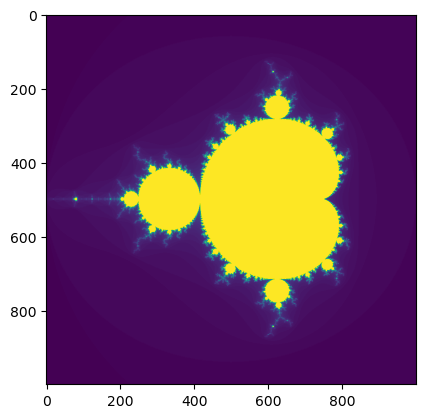

**Co je Mandelbrotova množina?**

Mandelbrotova množina je množina komplexních čísel $c$, pro které platí, že posloupnost $z_{i+1} = z_i^2 + c$ s $z_0 = 0$ nekonverguje do nekonečna (tj. $|z_i|$ zůstává omezené).

**Co tedy udělat?**
- vytvořte matici $n\times n$ komplexních čísel $c$ na intervalu $[-2, 1] \times [-1.5, 1.5]$ (pomocí `np.mgrid` nebo `np.meshgrid`),
    - využijte výhody vektorizace a toho, že NumPy umí násobit komplexní čísla,
- stanovte si počet iterací $k$, pro které budete testovat, zda posloupnost nedivergovala,
    - divergování posloupnosti poznáme tak, že $|z_i| > 2$ pro nějaké $i$,
- proveďte $k$ iterací posloupnosti $z_{i+1} = z_i^2 + c$ a zjistěte, ve které iteraci nastalo $|z_i| > 2$ (jakmile to nastane jednou, bude to platit pro všechna další $i$),
    - použijte pomocnou matici `divergence_matrix`, která bude mít stejný rozměr jako `c` a bude obsahovat počet iterací, kdy $|z_i| < 2$ pro každé $c$,
- vytvořte obrázek pomocí `imshow` z `divergence_matrix`.

In [9]:
def mandelbrot_set(x_min=-2, x_max=1, y_min=-1.5, y_max=1.5, n=1000, k=100):
    x = np.linspace(x_min, x_max, n)
    y = np.linspace(y_min, y_max, n)
    X, Y = np.meshgrid(x, y)
    C = X + 1j * Y
    Z = np.zeros_like(C)
    divergence_matrix = np.zeros(C.shape, dtype=int)

    for i in range(k):
        Z = Z**2 + C
        mask = (np.abs(Z) > 2) & (divergence_matrix == 0)
        divergence_matrix[mask] = i

    divergence_matrix[divergence_matrix == 0] = k
    return divergence_matrix

C:\Users\sevak\AppData\Local\Temp\ipykernel_19712\3445493864.py:10: RuntimeWarning: overflow encountered in square
  Z = Z**2 + C
C:\Users\sevak\AppData\Local\Temp\ipykernel_19712\3445493864.py:10: RuntimeWarning: invalid value encountered in square
  Z = Z**2 + C


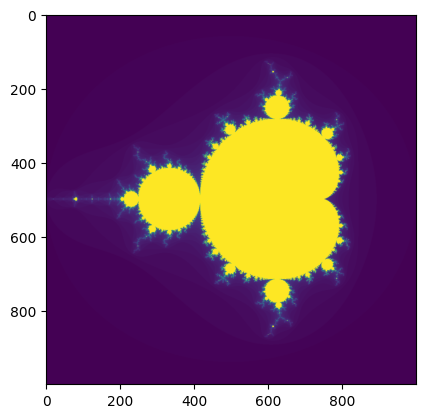

In [10]:
n = 1000
k = 100

divergence_matrix = mandelbrot_set(n=n, k=k)
plt.imshow(divergence_matrix)

## Bonusové úkoly
1. Vykreslete také Juliovu množinu (viz https://en.wikipedia.org/wiki/Julia_set).
2. Použijte váš kód pro číselnou spirálu a vytvořte obrázek prvočíselné spirály (viz https://en.wikipedia.org/wiki/Ulam_spiral).

In [11]:
def julia_set(c=-0.7+0.27015j, x_min=-1.5, x_max=1.5, y_min=-1.5, y_max=1.5, n=1000, k=100):
    x = np.linspace(x_min, x_max, n)
    y = np.linspace(y_min, y_max, n)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    divergence_matrix = np.zeros(Z.shape, dtype=int)

    for i in range(k):
        Z = Z**2 + c
        mask = (np.abs(Z) > 2) & (divergence_matrix == 0)
        divergence_matrix[mask] = i

    divergence_matrix[divergence_matrix == 0] = k
    return divergence_matrix

C:\Users\sevak\AppData\Local\Temp\ipykernel_19712\4216051102.py:9: RuntimeWarning: overflow encountered in square
  Z = Z**2 + c
C:\Users\sevak\AppData\Local\Temp\ipykernel_19712\4216051102.py:9: RuntimeWarning: invalid value encountered in square
  Z = Z**2 + c


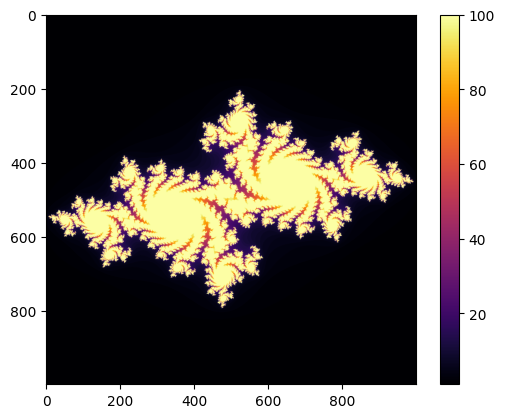

In [12]:
plt.imshow(julia_set(), cmap='inferno')
plt.colorbar()
plt.show()

In [15]:
def ulam_spiral(n):
    A = integer_spiral_numpy(n)
    primes = np.ones_like(A, dtype=bool)
    primes[A < 2] = False

    for i in range(2, int(np.sqrt(A.max())) + 1):
        primes[A % i == 0] = False
        primes[A == i] = True

    return primes

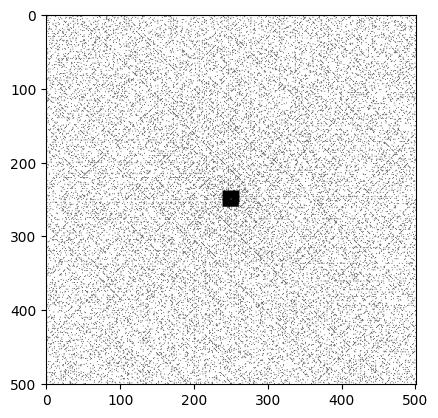

In [16]:
plt.imshow(ulam_spiral(501), cmap='binary')
plt.show()